# Oprec Ristek Data Science SIG

## Deskripsi data

In [ ]:
DATA_DIR = "../data/ristek_oprec_2022"

train_path = f"{DATA_DIR}/train.csv"
test_path = f"{DATA_DIR}/test.csv"
submission_path = f"{DATA_DIR}/sample_submission.csv"

In [ ]:
# Meng-import modul yang dibutuhkan
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Membaca train dataset
df = pd.read_csv(train_path)

In [ ]:
df.head() # Melihat sekilas dataset

id                  played_at  \
0  0205bd314da54b6fb363a998ca0c49ba  2022-02-25 03:01:50+00:00   
1  7ca6c874c8064364b4247780495fe4f2  2021-10-17 05:11:18+00:00   
2  92ccfb1330424a4fb572585b8d6ea4c9  2021-10-10 01:50:23+00:00   
3  d592c15de2a94b6aa5278b0fc241de54  2022-02-25 04:27:49+00:00   
4  6a24b0487aef460a982d2ec930947c11  2021-12-15 19:17:24+00:00   

               tournament                    map  game_length  winner matchup  \
0            IEM Katowice       2000 애트모스피어 - 래더          848       2     TvT   
1       DH Masters Winter  Beckett Industries LE          612       1     PvZ   
2       DH Masters Winter  Beckett Industries LE          486       2     PvZ   
3            IEM Katowice       [ESL] Berlingrad         1078       2     PvZ   
4  DH Masters Last Chance               블랙번 - 래더         1001       1     PvZ   

   p1_max_collection_rate  p2_max_collection_rate  p1_apm  ...  \
0                    3778                    3952     316  ...   
1                    4344                    3140     398  ...   
2                    3095                    2944     389  ...   
3                    4064                    4193     449  ...   
4                    4484                    4243     627  ...   

   p1_avg_collection_rate_gas  p1_avg_unspent_gas  p1_gas_lost  \
0                       533.8               273.8         3436   
1                       473.9               236.7          625   
2                       226.5               157.6          800   
3                       749.7               401.2         5850   
4                       826.1               299.8         8975   

   p1_gas_collected  p2_avg_collection_rate_gas  p2_avg_unspent_gas  \
0              6384                       636.3               253.2   
1              4265                       427.4               201.3   
2              1668                       336.1               170.0   
3             11682                       892.6               664.5   
4             11930                       675.6               174.5   

   p2_gas_lost  p2_gas_collected  p1_race  p2_race  
0         2864              7412   Terran   Terran  
1          850              3665     Zerg  Protoss  
2           75              2436     Zerg  Protoss  
3         3850             13344  Protoss     Zerg  
4         8200             10256     Zerg  Protoss  

[5 rows x 49 columns]

In [ ]:
train = df.copy() # Membuat salinan untuk training model

## Data Preprocessing dan Cleaning

In [ ]:
# Memeriksa apakah ada missing value
train.isnull().sum()

In [ ]:
# Memeriksa data yang mempunyai tipe objek

train.select_dtypes(include='object').columns

Index(['id', 'played_at', 'tournament', 'map', 'matchup', 'p1_race',
       'p2_race'],
      dtype='object')

In [ ]:
# Melihat apa yang ada di column played_at
train['played_at'].value_counts()

,count
played_at,
2021-12-15 17:13:26+00:00,2
2022-02-23 19:11:35+00:00,1
2022-02-25 01:15:37+00:00,1
2021-10-06 01:17:27+00:00,1
2021-12-18 03:48:10+00:00,1
...,...
2022-02-23 23:19:38+00:00,1
2022-02-24 19:33:55+00:00,1
2021-10-07 22:24:52+00:00,1


In [ ]:
# Melihat apa yang ada di column tournament
train['tournament'].value_counts()

,count
tournament,
DH Masters Winter,448
DH Masters Last Chance,224
IEM Katowice,157


In [ ]:
# Melihat apa yang ada di column map
train['map'].value_counts()

,count
map,
2000 Atmospheres LE,156
Jagannatha LE,64
Blackburn LE,62
Romanticide LE,60
Oxide LE,59
Lightshade LE,55
[ESL] Hardwire,32
2000 애트모스피어 - 래더,28
[ESL] Berlingrad,28


- column 'played_at' dirasa tidak membantu dalam prediksi race, maka akan di drop
- column 'tournament' dirasa tidak membantu dalam prediksi race, maka akan di drop
- column 'map' terlalu random wkwk

In [ ]:
train.drop(['played_at', 'id', 'matchup', 'map'], axis=1, inplace=True)

Cara yang akan saya gunakan untuk memprediksi matchup adalah dengan memprediksi race dari player 1 dan race dari player 2. Oleh karena itu, saya akan menyatukan data player 1 dengan data player 2 untuk training model. Sebelum disatukan, saya akan memisahkan data player 1 dan player 2 ke dataframe yang berbeda, lalu disatukan.

In [ ]:
# Membuat dataframe baru untuk player 1
datap1 = train.copy()
# Menghilangkan data player 2
for name in datap1.columns:
  if name[0:2] == 'p2':
    datap1.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 1
new_winner = []
for win in datap1['winner']:
  if win == 2:
    new_winner.append(0)
  else:
    new_winner.append(1)
datap1['winner'] = new_winner
# Menyamakan column name dengan dataframe player 2
datap1.columns = datap1.columns.str.replace("p1_", "")

In [ ]:
# Membuat dataframe baru untuk player 2
datap2 = train.copy()
# Menghilangkan data player 1
for name in datap2.columns:
  if name[0:2] == 'p1':
    datap2.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 2
new_winner = []
for win in datap2['winner']:
  if win == 2:
    new_winner.append(1)
  else:
    new_winner.append(0)
datap2['winner'] = new_winner
# Menyamakan column name dengan dataframe player 1
datap2.columns = datap2.columns.str.replace("p2_", "")

In [ ]:
# Membuat dataframe baru yang berupa gabungan dataframe player 1 dan player 2
newdf = pd.concat([datap1, datap2], axis=0)
newdf

tournament  game_length  winner  max_collection_rate  apm  \
0              IEM Katowice          848       0                 3778  316   
1         DH Masters Winter          612       1                 4344  398   
2         DH Masters Winter          486       0                 3095  389   
3              IEM Katowice         1078       0                 4064  449   
4    DH Masters Last Chance         1001       1                 4484  627   
..                      ...          ...     ...                  ...  ...   
824  DH Masters Last Chance         1059       0                 3471  415   
825       DH Masters Winter          473       0                 2625  410   
826       DH Masters Winter          650       1                 3510  335   
827            IEM Katowice          881       0                 3862  379   
828       DH Masters Winter          447       1                 2311  296   

      spm  workers_produced  workers_killed  workers_lost  supply_block  ...  \
0    26.3                75              18            17            75  ...   
1    42.9                97              22            21            30  ...   
2    35.9                80              11            17            20  ...   
3    40.2                77              68            30            15  ...   
4    37.6                98              24            25            25  ...   
..    ...               ...             ...           ...           ...  ...   
824  33.9                89              54            51            45  ...   
825  16.5                49               3             4            20  ...   
826  45.0                66               7             3             5  ...   
827  45.5               100              30            37            40  ...   
828  45.5                48              18             6            50  ...   

     avg_pac_gap  avg_collection_rate_minerals  avg_unspent_minerals  \
0           0.06                        1808.2                 241.2   
1           0.06                        1938.9                 473.6   
2           0.06                        1563.7                 232.1   
3           0.06                        2107.6                 535.6   
4           0.04                        2306.8                 259.8   
..           ...                           ...                   ...   
824         0.07                        1583.5                 341.4   
825         0.04                        1246.9                 150.1   
826         0.08                        1876.5                 268.4   
827         0.08                        1622.3                 292.6   
828         0.07                        1064.1                 122.5   

     minerals_lost  minerals_collected  avg_collection_rate_gas  \
0            10341               25162                    533.8   
1             3075               20305                    473.9   
2             4200               13525                    226.5   
3            13650               37470                    749.7   
4            21675               37048                    826.1   
..             ...                 ...                      ...   
824          12968               27055                    446.9   
825           1725               10705                    332.4   
826           8575               21220                    457.3   
827           5535               24609                    580.9   
828            475                8575                    269.3   

     avg_unspent_gas  gas_lost  gas_collected     race  
0              273.8      3436           6384   Terran  
1              236.7       625           4265     Zerg  
2              157.6       800           1668     Zerg  
3              401.2      5850          11682  Protoss  
4              299.8      8975          11930     Zerg  
..               ...       ...            ...      ...  
824            147.0      4018           6423     

In [ ]:
daftar_tour = newdf['tournament'].unique()
newdf['tournament'].value_counts()

,count
tournament,
DH Masters Winter,896
DH Masters Last Chance,448
IEM Katowice,314


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
# Possible to rearrange
tour = ["DH Masters Winter", "DH Masters Last Chance", "IEM Katowice"]
enc = OrdinalEncoder(categories=[tour])
newdf[["tournament"]] = enc.fit_transform(newdf[["tournament"]])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
newdf["race"]= le.fit_transform(newdf["race"])

In [ ]:
# Memisahkan antara fitur dan target
target = newdf['race']
ohetarget = pd.get_dummies(target, columns=["race"]) # ohe: One Hot Encoding
newdf.drop('race',axis=1, inplace=True)

## Pencarian Machine Learning Model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

In [ ]:
from sklearn.metrics import precision_score, \
    recall_score, classification_report, \
    accuracy_score, f1_score


def evaluate_classifier_performance(prediction, y_test, report=False, cm=False):
  # Spesific Metric
  print('Accuracy Average:', accuracy_score(y_test, prediction))
  print('F1 Macro Average:', f1_score(y_test, prediction, average='macro'))

  # Classification Report
  if report:
    print("Hasil Evaluasi berdasarkan classification report \n\n%s\n" % (classification_report(y_test, prediction,zero_division=0)))

  # Confussion Matrix
  if cm:
    y_actual = pd.Series(np.array(y_test), name = "actual")
    y_pred = pd.Series(np.array(prediction), name = "prediction")
    df_confusion = pd.crosstab(y_actual, y_pred)
    display(df_confusion)
  print()

In [ ]:
newdf.head()

tournament  game_length  winner  max_collection_rate  apm  \
0            IEM Katowice          848       0                 3778  316   
1       DH Masters Winter          612       1                 4344  398   
2       DH Masters Winter          486       0                 3095  389   
3            IEM Katowice         1078       0                 4064  449   
4  DH Masters Last Chance         1001       1                 4484  627   

    spm  workers_produced  workers_killed  workers_lost  supply_block  ...  \
0  26.3                75              18            17            75  ...   
1  42.9                97              22            21            30  ...   
2  35.9                80              11            17            20  ...   
3  40.2                77              68            30            15  ...   
4  37.6                98              24            25            25  ...   

   avg_pac_actions  avg_pac_gap  avg_collection_rate_minerals  \
0             8.11         0.06                        1808.2   
1             6.65         0.06                        1938.9   
2             9.47         0.06                        1563.7   
3             9.02         0.06                        2107.6   
4            11.50         0.04                        2306.8   

   avg_unspent_minerals  minerals_lost  minerals_collected  \
0                 241.2          10341               25162   
1                 473.6           3075               20305   
2                 232.1           4200               13525   
3                 535.6          13650               37470   
4                 259.8          21675               37048   

   avg_collection_rate_gas  avg_unspent_gas  gas_lost  gas_collected  
0                    533.8            273.8      3436           6384  
1                    473.9            236.7       625           4265  
2                    226.5            157.6       800           1668  
3                    749.7            401.2      5850          11682  
4                    826.1            299.8      8975          11930  

[5 rows x 23 columns]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Melakukan scaling data
scaler=StandardScaler()
newdf=pd.DataFrame(scaler.fit_transform(newdf), columns=newdf.columns)

newdf
# Melakukan splitting menjadi train dan validation
X_train, X_valid, y_train, y_valid = train_test_split(newdf, target,
                                                    test_size=0.2, random_state=1)
X_train, X_valid, ohe_train, ohe_valid = train_test_split(newdf, ohetarget,
                                                    test_size=0.2, random_state=1)

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(1326, 23) (1326,)
(332, 23) (332,)


In [ ]:
n_fold = 5
folds = StratifiedKFold(n_splits=n_fold, random_state = 42, shuffle=True)
splits = folds.split(newdf, target)
score_total = 0
for count , (train_index, valid_index) in enumerate(splits):
  X_tr, X_val = newdf.iloc[train_index], newdf.iloc[valid_index]
  y_tr, y_val = target.iloc[train_index], target.iloc[valid_index]
  weights = {0:5000, 1:3000, 2:5000, 3:15000}
  rfc = RandomForestClassifier()
  rfc.fit(X_tr, y_tr)
  clf_result = rfc.predict(X_val)
  score = f1_score(y_val, clf_result, average='macro')
  score_total += score
  print(f"Result iteration-{count}")
  evaluate_classifier_performance(clf_result, y_val)

# Final Result
print(f"Combination F1 SCORE {score_total/5}")

Result iteration-0
Accuracy Average: 0.8192771084337349
F1 Macro Average: 0.8188454603429222

Result iteration-1
Accuracy Average: 0.8313253012048193
F1 Macro Average: 0.8320019281273893

Result iteration-2
Accuracy Average: 0.8313253012048193
F1 Macro Average: 0.830014450718949

Result iteration-3
Accuracy Average: 0.8066465256797583
F1 Macro Average: 0.808649321625624

Result iteration-4
Accuracy Average: 0.7764350453172205
F1 Macro Average: 0.7754970936879223

Combination F1 SCORE 0.8130016509005612


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8524096385542169


In [ ]:
print(rfc.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [ ]:
# Training menggunakan Support Vector Classification model

from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)
pred2 = svc.predict(X_valid)
print(accuracy_score(y_valid, pred2))

0.8433734939759037


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
pred3 = xgb.predict(X_valid)
print(accuracy_score(y_valid, pred3))

0.8734939759036144


In [ ]:
# Mengisntall modul catboost
!pip install catboost > /dev/null

In [ ]:
# Melatih dan mengevaluasi model catboost regressor

from catboost import CatBoostClassifier

cb = CatBoostClassifier(silent=True)
cb.fit(X_train, y_train)
pred4 = cb.predict(X_valid)
print(accuracy_score(y_valid, pred4))

0.9006024096385542


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error

bc = GradientBoostingClassifier()
bc.fit(X_train, y_train)
pred = bc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8704819277108434


In [ ]:
# Training menggunakan Random Forest Classifier model
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error

bc = HistGradientBoostingClassifier()
bc.fit(X_train, y_train)
pred = bc.predict(X_valid)
print(accuracy_score(y_valid, pred))

0.8885542168674698


In [ ]:
# Menggunakan fungsi Callback

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import TensorBoard

# Fungsi callback untuk memplotting loss
tensor_board = TensorBoard(log_dir='./Graph', histogram_freq=1,
                            write_graph=True, write_images=True)

# Fungsi callback untuk mereduksi learning rate bila tidak mengalami penurunan loss
reduce_lr = ReduceLROnPlateau(
    monitor = 'loss',
    factor = 0.4,
    patience = 5,
    verbose = 1)

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dropout, BatchNormalization
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adadelta, RMSprop

model2 = Sequential()
model2.add(Dense(256, input_shape = (23,), activation = "selu")) # Manage input size

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(256, activation = "selu"))

model2.add(Dropout(0.1))
model2.add(BatchNormalization())
model2.add(Dense(128, activation = "selu"))

model2.add(Dropout(0.05))
model2.add(Dense(3, activation = "softmax")) # Number of class on final dense layer
model2.compile(SGD(), "categorical_crossentropy", metrics = ["accuracy"])

model2.summary()

model2.fit(X_train, ohe_train, verbose=1, epochs=150, validation_split = 0.2, callbacks = [reduce_lr,tensor_board])
deep1 = model2.predict(X_valid)
deep1 = np.argmax(deep1, axis=1)
print(accuracy_score(y_valid, deep1))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 256)                 │           6,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 107,267 (419.01 KB)

 Trainable params: 106,243 (415.01 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5763 - loss: 0.9542 - val_accuracy: 0.6729 - val_loss: 0.8093 - learning_rate: 0.0100
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6781 - loss: 0.7846 - val_accuracy: 0.5564 - val_loss: 0.8988 - learning_rate: 0.0100
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6954 - loss: 0.7042 - val_accuracy: 0.6917 - val_loss: 0.6684 - learning_rate: 0.0100
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7678 - loss: 0.6127 - val_accuracy: 0.7331 - val_loss: 0.6234 - learning_rate: 0.0100
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7442 - loss: 0.6287 - val_accuracy: 0.7143 - val_loss: 0.6172 - learning_rate: 0.0100
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7405 - loss: 0.6157 - val_accuracy: 0.7406 - val_loss: 0.5999 - learning_rate: 0.0100
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7745 - loss: 0.5585 - 

In [ ]:
print(deep1)

[0 1 2 1 0 1 1 2 1 2 0 1 2 1 0 2 1 0 2 0 0 0 1 2 1 2 1 2 0 2 0 1 2 1 0 1 1
 0 2 1 1 2 0 1 1 1 2 0 2 1 0 2 1 2 0 0 1 1 2 1 1 2 2 0 0 2 1 1 1 1 2 0 0 2
 0 1 2 2 2 1 0 1 0 0 0 0 0 0 2 2 2 0 1 2 0 1 0 2 0 0 2 0 0 1 2 2 0 2 1 0 0
 2 0 0 0 0 2 2 0 0 0 0 2 1 2 0 1 0 1 0 1 1 1 0 1 1 1 2 1 2 0 0 0 1 1 1 2 0
 0 0 0 1 2 0 2 2 2 2 2 0 2 2 2 0 1 0 0 2 0 1 0 0 2 2 0 2 2 1 0 0 2 2 0 2 1
 0 1 0 2 0 0 0 2 1 0 1 2 1 1 0 0 0 2 1 1 0 2 0 2 0 1 0 2 0 0 0 1 1 1 0 1 2
 0 2 1 0 2 0 0 1 2 1 2 0 0 1 0 1 2 1 0 0 1 2 0 0 0 2 2 1 1 0 2 1 1 2 0 1 0
 0 2 0 0 2 2 0 1 0 1 0 1 0 2 1 2 0 2 0 0 1 1 2 2 0 0 1 1 0 0 1 2 0 1 2 0 2
 2 1 2 1 0 1 2 1 2 0 0 0 2 0 0 0 1 1 2 1 0 0 0 2 1 2 2 1 1 0 0 0 0 2 0 1]


In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/Graph
from tensorboard import notebook
notebook.list()

Output hidden; open in https://colab.research.google.com to view.

## Deep Neural Network

## Hyperparameter Tuning

TODO: Change to Optuna

In [ ]:
# Membuat self defined accuracy metric

from sklearn.metrics import make_scorer

def func(y_true, y_predicted):
    accuracy = accuracy_score(y_true, y_predicted)
    return accuracy

accuracy = make_scorer(func, greater_is_better=True)

In [ ]:
# Mencari hyperparameter terbaik untuk Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import RandomizedSearchCV

# Menggunakan cross validation untuk mencari parameter
model = RandomForestClassifier()
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=1)
space = {'max_features': ['auto', 'sqrt'],
         'max_depth': [2,4],
         'min_samples_split': [2],
         'min_samples_leaf': [1],
         'bootstrap': [True, False]}

search = RandomizedSearchCV(model, space, n_iter=50,
                            scoring=accuracy,
                            n_jobs=-1, cv=cv,
                            random_state=1,
                            verbose=2)

result = search.fit(X_train, y_train)
print(result.best_score_)
print(result.best_params_)
result.best_estimator_

Fitting 15 folds for each of 8 candidates, totalling 120 fits


KeyboardInterrupt: ignored

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)
print(grid.best_score_)
print(grid.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.391 total time=   0.3s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.4s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.3s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.4s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.389 total time=   0.3s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.733 total time=   0.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.725 total time=   0.3s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.725 total time=   0.3s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.709 total time=   0.3s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.717 total time=   0.2s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.699 total time=   0.3s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

xgb = XGBClassifier()

paramgrid = {'colsample_bytree': [0.75],
             'gamma': [0.1, 0.05],
             'learning_rate': [0.1, 0.05],
             'min_child_weight': [0.01],
             'n_estimators': [500],
             'reg_alpha': [1],
             'reg_lambda': [2],
             'sampling_method': ['uniform'],
             'subsample': [0.55]}

gridxgb = GridSearchCV(xgb, paramgrid,
                    scoring=accuracy,
                    cv=cv, n_jobs=-1,
                    verbose=2)

gridxgb.fit(X_train, y_train)
print(gridxgb.best_params_)
pred = gridxgb.predict(X_valid)
print(accuracy_score(y_valid, pred))

## Hasil Prediksi Test Data

Parameter yang digunakan sudah melalui tuning manual:)

In [ ]:
# Melatih dan mengevaluasi model support vector regressor

from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV

svc = SVC(C = 100, gamma = 0.008, kernel = 'rbf')
svc.fit(X_train, y_train)
pred1 = svc.predict(X_valid)
print(accuracy_score(y_valid, pred1))

0.9066265060240963


In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(colsample_bytree = 0.75,
                    gamma = 0.1,
                    learning_rate = 0.1,
                    min_child_weight = 0.015,
                    n_estimators = 500,
                    reg_alpha = 1,
                    reg_lambda = 2,
                    sampling_method = 'uniform',
                    subsample = 0.55)
xgb = xgb.fit(X_train,y_train)
pred2 = xgb.predict(X_valid)
print(accuracy_score(y_valid, pred2))

0.9126506024096386


In [ ]:
# Melatih dan mengevaluasi model catboost regressor

from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations = 1000, # 1000 are ideal
    loss_function='MultiClass',
    eval_metric = 'MultiClass',
    leaf_estimation_iterations = 100,
    random_strength = 0.5,
    depth = 6,
    l2_leaf_reg = 5,
    learning_rate=0.05,
    bagging_temperature = 0.8,
)
cb.fit(X_train, y_train)
pred3 = cb.predict(X_valid)
print(accuracy_score(y_valid, pred3))

0:	learn: 1.0452076	total: 50.7ms	remaining: 50.7s
1:	learn: 1.0037755	total: 96.1ms	remaining: 48s
2:	learn: 0.9675784	total: 143ms	remaining: 47.5s
3:	learn: 0.9276103	total: 189ms	remaining: 47.1s
4:	learn: 0.8979113	total: 235ms	remaining: 46.8s
5:	learn: 0.8650746	total: 284ms	remaining: 47s
6:	learn: 0.8398574	total: 336ms	remaining: 47.7s
7:	learn: 0.8121134	total: 391ms	remaining: 48.5s
8:	learn: 0.7827142	total: 439ms	remaining: 48.3s
9:	learn: 0.7559351	total: 489ms	remaining: 48.4s
10:	learn: 0.7383606	total: 536ms	remaining: 48.2s
11:	learn: 0.7213340	total: 583ms	remaining: 48s
12:	learn: 0.7036403	total: 628ms	remaining: 47.7s
13:	learn: 0.6894929	total: 676ms	remaining: 47.6s
14:	learn: 0.6763641	total: 800ms	remaining: 52.5s
15:	learn: 0.6650024	total: 875ms	remaining: 53.8s
16:	learn: 0.6546509	total: 924ms	remaining: 53.4s
17:	learn: 0.6418094	total: 971ms	remaining: 53s
18:	learn: 0.6296114	total: 1.02s	remaining: 52.7s
19:	learn: 0.6201925	total: 1.06s	remaining: 52

[[ 85  10]
 [  8 119]]


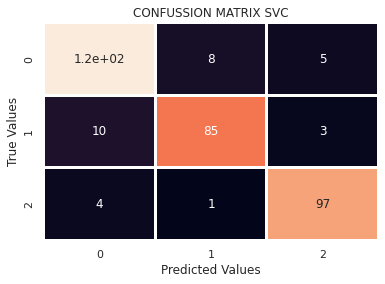

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred1,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred1),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX SVC")
plt.show()

[[ 86  10]
 [  7 122]]


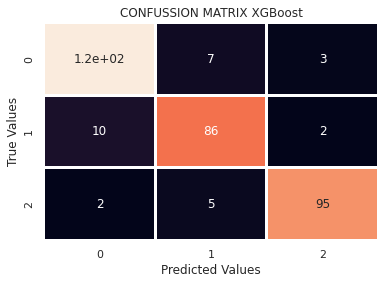

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred2,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred2),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX XGBoost")
plt.show()

[[ 86  10]
 [  7 120]]


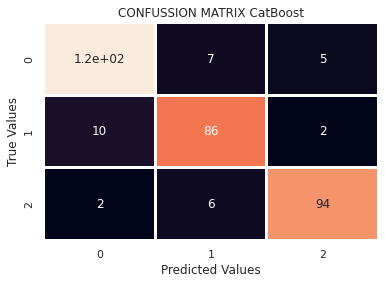

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_valid,pred3,labels=[1,0]))
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_valid,pred3),annot=True,lw =2,cbar=False)
plt.ylabel("True Values")
plt.xlabel("Predicted Values")
plt.title("CONFUSSION MATRIX CatBoost")
plt.show()

## Training Model 100%

In [ ]:
# Melatih dan mengevaluasi model support vector regressor

from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV

svc = SVC(C = 100, gamma = 0.008, kernel = 'rbf')
svc.fit(newdf, target)

SVC(C=100, gamma=0.008)

In [ ]:
# Mencari hyperparameter terbaik untuk XGBoost
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(colsample_bytree = 0.75,
                    gamma = 0.1,
                    learning_rate = 0.1,
                    min_child_weight = 0.015,
                    n_estimators = 500,
                    reg_alpha = 1,
                    reg_lambda = 2,
                    sampling_method = 'uniform',
                    subsample = 0.55)
xgb = xgb.fit(newdf,target)

In [ ]:
# Melatih dan mengevaluasi model CatBoost Classifier

from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    iterations = 1000, # 1000 are ideal
    loss_function='MultiClass',
    eval_metric = 'MultiClass',
    leaf_estimation_iterations = 100,
    random_strength = 0.5,
    depth = 6,
    l2_leaf_reg = 5,
    learning_rate=0.05,
    bagging_temperature = 0.8,
)
cb.fit(newdf, target)

0:	learn: 1.0422881	total: 76.6ms	remaining: 1m 16s
1:	learn: 0.9996575	total: 139ms	remaining: 1m 9s
2:	learn: 0.9514666	total: 228ms	remaining: 1m 15s
3:	learn: 0.9185301	total: 373ms	remaining: 1m 32s
4:	learn: 0.8885615	total: 498ms	remaining: 1m 39s
5:	learn: 0.8546738	total: 580ms	remaining: 1m 36s
6:	learn: 0.8249850	total: 642ms	remaining: 1m 31s
7:	learn: 0.8030100	total: 804ms	remaining: 1m 39s
8:	learn: 0.7789828	total: 935ms	remaining: 1m 42s
9:	learn: 0.7604243	total: 992ms	remaining: 1m 38s
10:	learn: 0.7383909	total: 1.05s	remaining: 1m 34s
11:	learn: 0.7221850	total: 1.12s	remaining: 1m 31s
12:	learn: 0.7020050	total: 1.19s	remaining: 1m 30s
13:	learn: 0.6817552	total: 1.31s	remaining: 1m 32s
14:	learn: 0.6664107	total: 1.45s	remaining: 1m 35s
15:	learn: 0.6537737	total: 1.58s	remaining: 1m 37s
16:	learn: 0.6409314	total: 1.68s	remaining: 1m 36s
17:	learn: 0.6294457	total: 1.74s	remaining: 1m 34s
18:	learn: 0.6192254	total: 1.83s	remaining: 1m 34s
19:	learn: 0.6071637	t

## Model Deployment

In [ ]:
test = pd.read_csv('/content/test.csv')

In [ ]:
test.drop(['played_at', 'tournament', 'id', 'map'], axis=1, inplace=True)

In [ ]:
# Membuat dataframe baru untuk player 1
testp1 = test.copy()
# Menghilangkan data player 2
for name in testp1.columns:
  if name[0:2] == 'p2':
    testp1.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 1
new_winner = []
for win in testp1['winner']:
  if win == 2:
    new_winner.append(0)
  else:
    new_winner.append(1)
testp1['winner'] = new_winner
# Menyamakan column name dengan dataframe player 2
testp1.columns = testp1.columns.str.replace("p1_", "")

In [ ]:
# Membuat dataframe baru untuk player 2
testp2 = test.copy()
# Menghilangkan data player 1
for name in testp2.columns:
  if name[0:2] == 'p1':
    testp2.drop([name], axis=1, inplace=True)
# Mendapatkan status kemenangan player 2
new_winner = []
for win in testp2['winner']:
  if win == 2:
    new_winner.append(1)
  else:
    new_winner.append(0)
testp2['winner'] = new_winner
# Menyamakan column name dengan dataframe player 1
testp2.columns = testp2.columns.str.replace("p2_", "")

In [ ]:
testp1=pd.DataFrame(scaler.fit_transform(testp1), columns=testp1.columns)
testp2=pd.DataFrame(scaler.fit_transform(testp2), columns=testp2.columns)

In [ ]:
hasilp1a = svc.predict(testp1)
hasilp1b = xgb.predict(testp1)
hasilp1c = cb.predict(testp1)
hasilp1c = hasilp1c.flatten()

hasilp2a = svc.predict(testp2)
hasilp2b = xgb.predict(testp2)
hasilp2c = cb.predict(testp2)
hasilp2c = hasilp2c.flatten()

print(hasilp1a)
print(hasilp2b)

[1 1 0 0 2 1 1 0 2 0 2 2 1 1 0 1 0 0 0 0 1 0 2 0 2 0 1 1 1 0 1 0 2 2 1 2 2
 0 0 1 1 1 0 1 1 1 1 0 0 1 2 0 1 1 1 1 0 2 2 0 2 0 0 1 0 0 2 0 2 2 0 0 0 1
 0 1 2 1 1 1 2 1 0 2 1 2 1 0 0 1 0 2 0 0 1 0 0 2 1 1 2 0 2 1 0 2 1 2 0 1 0
 1 0 1 2 1 2 0 2 2 0 1 0 2 2 2 0 0 0 1 2 0 0 2 2 1 1 2 1 0 1 1 0 2 0 1 1 2
 2 0 0 0 0 0 1 0 1 1 2 2 1 1 0 1 1 2 1 0 1 2 1 0 1 0 1 0 1 2 2 0 1 1 0 1 2
 0 1 2 1 2 0 2 1 2 0 2 2 0 2 2 0 2 0 2 1 2 0 1 1 0 0 1 1 1 1 0 2 1 2 0 1 1
 2 0 1 1 0 0 2 1 2 2 1 2 0 2 1 2 0 0 0 0 2 2 0 0 0 2 0 0 0 1 1 0 1 1 0 2 2
 2 2 2 2 1 2 0 0 1 0 1 2 1 1 0 2 1 2 0 0 0 2 0 0 0 0 0 0 0 0 1 0 2 2 0 2 0
 1 2 0 1 0 1 2 1 0 2 1 2 2 2 1 1 0 0 1 1 2 1 1 2 1 0 2 0 1 2 1 2 2 0 0 0 0
 1 1 0 2 2 0 0 1 1 1 0 0 1 0 0 0 1 0 2 2 0 0 0 2 0 1 2 2 0 0 2 2 0 1 2 2 2
 1 0 2 0 0 0 2 1 1 2 2 0 1 0 0 1 0 0 0 0 0 2 2 2 0 0 1 0 0 2 0 1 2 0 2 0 1
 0 2 1 1 2 1 2 1 1 1 0 1 2 2 1 1 1 0 0 2 0 1 1 2 0 2 0 0 2 0 0 0 2 2 1 1 0
 1 1 0 2 0 1 0 1 1 2 2 1 1 0 1 0 2 0 0 1 0 0 2 1 0 0 1 0 1 2 2 1 0 2 0 0 0
 1 1 1 2 0 1 0 1 2 2 2 2 

In [ ]:
hasilp1a = le.inverse_transform(hasilp1a)
hasilp1b = le.inverse_transform(hasilp1b)
hasilp1c = le.inverse_transform(hasilp1c)

hasilp2a = le.inverse_transform(hasilp2a)
hasilp2b = le.inverse_transform(hasilp2b)
hasilp2c = le.inverse_transform(hasilp2c)

In [ ]:
campur = []

for a,b,c in zip(hasilp1a, hasilp1b, hasilp1c):
  if a==b:
    campur.append(a)
  elif a==c:
    campur.append(a)
  elif b==c:
    campur.append(b)
  else:
    campur.append(b)

In [ ]:
campur2 = []

for a,b,c in zip(hasilp2a, hasilp2b, hasilp2c):
  if a==b:
    campur2.append(a)
  elif a==c:
    campur2.append(a)
  elif b==c:
    campur2.append(b)
  else:
    campur2.append(b)

In [ ]:
final = []
for race1,race2 in zip(campur,campur2):
  temp = []
  temp.append(race1)
  temp.append(race2)
  if sorted(temp) == ['Terran','Zerg']:
    final.append('TvZ')
  elif sorted(temp) == ['Protoss','Terran']:
    final.append('TvP')
  elif sorted(temp) == ['Protoss', 'Zerg']:
    final.append('PvZ')
  elif set(temp) == {'Protoss'}:
    final.append('PvP')
  elif set(temp) == {'Terran'}:
    final.append('TvT')
  elif set(temp) == {'Zerg'}:
    final.append('ZvZ')
  else:
    print(set(temp))
    print('aneh')

In [ ]:
print(final)

['TvP', 'TvP', 'TvP', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'TvP', 'PvZ', 'PvP', 'PvZ', 'PvZ', 'TvP', 'TvZ', 'TvP', 'TvT', 'PvP', 'TvP', 'PvZ', 'PvP', 'TvP', 'PvP', 'PvZ', 'TvP', 'ZvZ', 'PvP', 'PvP', 'TvP', 'TvP', 'PvP', 'TvZ', 'PvP', 'PvZ', 'TvZ', 'TvT', 'TvZ', 'PvZ', 'TvP', 'PvP', 'TvT', 'TvZ', 'TvP', 'PvP', 'TvP', 'TvT', 'TvP', 'TvT', 'TvZ', 'PvP', 'TvT', 'TvZ', 'PvP', 'TvZ', 'TvP', 'TvZ', 'TvP', 'TvT', 'TvZ', 'ZvZ', 'PvP', 'PvZ', 'TvP', 'PvZ', 'TvZ', 'TvP', 'TvP', 'PvZ', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'PvP', 'PvZ', 'TvZ', 'PvP', 'TvT', 'TvZ', 'TvP', 'TvT', 'TvZ', 'ZvZ', 'TvP', 'TvP', 'PvZ', 'TvZ', 'ZvZ', 'TvP', 'PvZ', 'TvP', 'TvZ', 'PvZ', 'TvZ', 'TvZ', 'TvP', 'PvZ', 'TvP', 'PvZ', 'TvZ', 'TvP', 'TvT', 'PvZ', 'PvZ', 'PvZ', 'TvZ', 'PvZ', 'PvZ', 'TvP', 'TvZ', 'PvZ', 'TvT', 'PvP', 'TvT', 'PvP', 'TvP', 'TvZ', 'PvP', 'ZvZ', 'PvP', 'ZvZ', 'TvZ', 'TvP', 'TvT', 'TvP', 'ZvZ', 'PvZ', 'PvZ', 'TvP', 'PvP', 'PvP', 'TvT', 'PvZ', 'TvP', 'TvP', 'PvZ', 'ZvZ', 'TvZ', 'TvT', 'PvZ', 'TvP', 'PvP', 'ZvZ', 'TvT', 'PvP'

In [ ]:
submission = pd.read_csv('/content/submission.csv')
submission

,id,matchup
0,486d95087ff4445da692067dfdbd3870,ZvZ
1,2de9f70785c848f8bb580f188c4f0302,ZvZ
2,38ca5b10579f4dc9b7d5b54c5271afab,ZvZ
3,bf780984dd2f403ba3668a2997b89841,ZvZ
4,8c59ca38e232444bb30648cc9f2d221e,ZvZ
...,...,...
549,4969f529046c418ab915071957a94693,ZvZ
550,2fca4fed571e4d15ae0bf1b321702edf,ZvZ
551,27b0d332225b4c74937f8dc5f6aabbff,ZvZ
552,aae99b57bebe4c6c9ce9dadb63c3515f,ZvZ


In [ ]:
submission['matchup'] = final
submission

,id,matchup
0,486d95087ff4445da692067dfdbd3870,TvP
1,2de9f70785c848f8bb580f188c4f0302,TvP
2,38ca5b10579f4dc9b7d5b54c5271afab,TvP
3,bf780984dd2f403ba3668a2997b89841,PvZ
4,8c59ca38e232444bb30648cc9f2d221e,TvZ
...,...,...
549,4969f529046c418ab915071957a94693,TvP
550,2fca4fed571e4d15ae0bf1b321702edf,PvP
551,27b0d332225b4c74937f8dc5f6aabbff,TvP
552,aae99b57bebe4c6c9ce9dadb63c3515f,ZvZ


In [ ]:
submission.to_csv('seventhtry.csv', index=False)